Detección de Exoplanetas con Redes Neuronales de Impulsos (SNN) inspiradas en el sistema visual de la mosca

La Idea
Usar la arquitectura del sistema visual de la mosca (que está muy bien mapeado en el conectoma) para construir una SNN que detecte tránsitos exoplanetarios en curvas de luz de misiones como Kepler o TESS.

¿Por qué la mosca?
El sistema visual de la Drosophila está optimizado para una tarea muy específica: detectar objetos pequeños que se mueven contra un fondo ruidoso. Un tránsito exoplanetario es exactamente eso: una caída minúscula y periódica en el brillo de una estrella (a veces del 0.01%) inmersa en ruido estelar y de instrumentación. Los circuitos de detección de movimiento de la mosca (como los de la vía de los lóbulos ópticos) son maestros en filtrar ruido y amplificar señales débiles.

Viabilidad
Dataset: Las curvas de luz de Kepler/TESS son públicas y manejables. Se pueden descargar 10,000-50,000 curvas de luz (cada una de ~1,000-10,000 puntos) y caben perfectamente en la RAM de este equipo

Modelo: Una SNN con la topología de una partición del lóbulo óptico (por ejemplo, 5,000-10,000 neuronas) es entrenable en Google Colab en pocas horas.

Ventaja: Las SNN son energéticamente eficientes, lo cual es relevante para futuros telescopios espaciales con procesamiento a bordo.

Una red neuronal de impulsos (SNN), o Spiking Neural Network, es un modelo de inteligencia artificial que imita el funcionamiento biológico del cerebro utilizando impulsos eléctricos discretos en lugar de valores continuos.

¿Qué es y cómo funciona?
• Impulsos discretos: A diferencia de las redes tradicionales que procesan datos de forma continua, las SNN funcionan mediante eventos o "pulsos" (spikes).
• Umbral de disparo: Una neurona acumula carga eléctrica y solo emite un impulso (señal a otras neuronas) cuando supera un umbral de voltaje específico.
• Factor temporal: El tiempo es clave en la simulación; la información se transmite según el momento exacto o la frecuencia con la que ocurren estos impulsos.

Ventajas principales
• Eficiencia energética: Consumen mucha menos energía porque las neuronas solo se activan cuando es necesario y no operan de forma simultánea todo el tiempo.
• Procesamiento temporal: Son ideales para analizar datos en tiempo real que cambian constantemente, como sensores de movimiento o visión artificial basada en eventos.
• Mayor realismo biológico: Se les considera la tercera generación de redes neuronales, acercándose más a la adaptabilidad del cerebro humano

CONECTOMA:

Un conectoma es un mapa integral de las conexiones neuronales que existen en un sistema nervioso, comúnmente comparado con un "diagrama de cableado" o un "Google Maps" del cerebro.

Tipos de Conectoma
• Estructural: Muestra las conexiones físicas directas entre las neuronas a través de axones y sinapsis.
• Funcional: Muestra cómo distintas áreas del cerebro trabajan y se comunican de forma coordinada sin requerir un vínculo físico directo

RUTA DEL PROCESO:

Los Datos: Usa el dataset de Kepler ("Kepler Labelled Time Series Data") en Kaggle. Viene en dos archivos CSV: exoTrain.csv (5,087 estrellas con 3,198 puntos de brillo cada una) y exoTest.csv (570 estrellas). Cada fila tiene una etiqueta: 2 para confirmado y 1 para no confirmado.

El Modelo: Empieza con una red feed-forward simple en PyTorch para entender el problema. La clave es lidiar con el desbalance de clases (hay muchas más estrellas sin planetas), una trampa que ya está documentada en proyectos similares. Una vez que domines eso, sustituye la capa densa por neuronas snn.Leaky de snnTorch. Esto le da al modelo una "memoria" temporal, que es perfecta para secuencias.

El Valor de la prueba: No solo replica un detector, sino que explora si la arquitectura inspirada en el sistema visual de la mosca (que detecta movimiento contra ruido) es más robusta para encontrar el "parpadeo" sutil de un tránsito planetario.

--- Una red neuronal prealimentada (o feed-forward) es un tipo de red artificial donde la información fluye en una sola dirección: desde la entrada hasta la salida, sin formar ciclos o bucles --- No guarda "memoria" de los datos

In [ ]:
! - VERIFICACIÓN QUE FUNCIONA LA INSTALACIÓN (TEST)

In [19]:
import os
print("Directorio actual:", os.getcwd())
print("\nContenido de ../data/:")
if os.path.exists('../data'):
    for f in os.listdir('../data'):
        print(f"  {f}")
else:
    print("  ¡No existe ../data/!")

Directorio actual: d:\AI\Conectoma\exoplanetas-snn\notebooks

Contenido de ../data/:
  exoTest.csv
  exoTrain.csv
  X_test.npy
  X_test_processed.npy
  X_train.npy
  X_train_processed.npy
  y_test.npy
  y_train.npy


In [ ]:
# ============================================================
# 1 — Carga de datos crudos y análisis de percentiles globales
# ============================================================
# En este bloque:
#   - Cargamos los arrays crudos desde los archivos .npy.
#   - Verificamos sus shapes.
#   - Calculamos percentiles globales de TODOS los valores de flujo.
#
# Este análisis es útil para:
#   - Identificar la presencia de outliers extremos.
#   - Evaluar la escala general de la señal.
#   - Decidir si es necesario aplicar recorte (clip), normalización robusta
#     o suavizado antes del modelado.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# ============================================================
# 1 — Cargar datos crudos desde .npy
# ============================================================

X_train = np.load('../data/X_train.npy')
y_train = np.load('../data/y_train.npy')
X_test  = np.load('../data/X_test.npy')
y_test  = np.load('../data/y_test.npy')

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

# ============================================================
# 2 — Percentiles globales de la distribución de flujo
# ============================================================
# Calculamos percentiles sobre TODOS los valores de X_train.
# Esto nos da una idea del rango dinámico de la señal y del nivel
# de ruido extremo presente en el dataset.

percentiles = [0.1, 1, 5, 50, 95, 99, 99.9]

print("\nPercentiles globales de TODOS los valores de flujo:")
for p in percentiles:
    val = np.percentile(X_train, p)
    print(f"  P{p:>5}: {val:>15.2f}")

# ============================================================
# Nota técnica
# ============================================================
# Los percentiles permiten observar:
#   - Si hay valores extremadamente altos o bajos (outliers).
#   - Si la distribución está sesgada.
#   - Si el rango dinámico es amplio (lo cual puede dificultar el modelado).
#
# Por ejemplo:
#   - Un P99 muy alto indica picos instrumentales.
#   - Un P0.1 muy bajo puede indicar

X_train: (5087, 3197)
X_test:  (570, 3197)

Percentiles globales de TODOS los valores de flujo:
  P  0.1:       -67020.19
  P    1:        -2791.00
  P    5:         -232.69
  P   50:            0.00
  P   95:          244.13
  P   99:         2738.32
  P 99.9:        66734.00


el P0.1 y el P99.9 serán valores muy extremos. El P50 (mediana) estará cerca de 0. Esto te muestra cuán asimétrica es la distribución

Percentil	        Valor	            Lo que significa
P0.1	            -67,020	            Outliers extremos negativos
P1	                -2,791	            Umbral inferior de clipping
P5	                -232	            Rango normal de variación
P50	                0	                Mediana centrada en cero
P95	                +244	            Rango normal de variación
P99	                +2,738	            Umbral superior de clipping
P99.9	            +66,734	            Outliers extremos positivos

Lo Que Estos Números Revelan
La distribución es simétrica: P5 y P95 son casi iguales en magnitud (-232 vs +244). Lo mismo con P1 y P99 (-2791 vs +2738). Esto es buena señal: la mayoría del "ruido" es simétrico.

El rango "normal" es minúsculo: entre P5 y P95 solo hay ~500 unidades. Pero el P0.1 y P99.9 se extienden a ±67,000. Eso significa que el 0.2% de los datos son outliers masivos que dominan la estadística global.

El clipping P1-P99 preserva el tránsito: los tránsitos que vimos antes (caídas de -1000 a -1400) están dentro del rango P1-P99 (-2791 a +2738). Así que al recortar a P1/P99, NO perdemos la señal, solo eliminamos los picos absurdos.

Por qué la normalización estándar fallaba: si calculas (x - media) / std, la std se infla por los outliers (±67,000) y la señal del tránsito (~1,000) queda diluida a ~1.5% de la escala. Con mediana/MAD, en cambio, la escala se define por el rango normal (±250) y el tránsito destaca mucho más.


In [22]:
# ============================================================
# 21 — Pipeline completo de preprocesamiento (versión final)
# ============================================================
# Este bloque implementa el pipeline final que usaremos en todos los
# notebooks de modelado. El pipeline combina:
#
#   1) clip_outliers      → Recorte por percentiles (1–99)
#   2) robust_normalize   → Normalización robusta (mediana + MAD)
#   3) smooth_curves      → Suavizado Savitzky–Golay
#   4) post_clip          → Recorte final para acotar el rango
#
# El resultado es una señal limpia, estable y comparable entre estrellas,
# ideal para modelos de clasificación basados en patrones temporales.

import numpy as np
from scipy.signal import savgol_filter

# ------------------------------------------------------------
# 1 — Recorte de outliers
# ------------------------------------------------------------
def clip_outliers(X, low_pct=1, high_pct=99):
    p_low  = np.percentile(X, low_pct,  axis=1, keepdims=True)
    p_high = np.percentile(X, high_pct, axis=1, keepdims=True)
    return np.clip(X, p_low, p_high)

# ------------------------------------------------------------
# 2 — Normalización robusta (mediana + MAD)
# ------------------------------------------------------------
def robust_normalize(X, mad_floor=0.05):
    median = np.median(X, axis=1, keepdims=True)
    mad    = np.median(np.abs(X - median), axis=1, keepdims=True)
    # Piso mínimo: MAD nunca menor al 5% de la std de la curva
    mad    = np.maximum(mad, mad_floor * X.std(axis=1, keepdims=True))
    return (X - median) / (1.4826 * mad + 1e-8)

# ------------------------------------------------------------
# 3 — Suavizado Savitzky–Golay
# ------------------------------------------------------------
def smooth_curves(X, window=31, polyorder=2):
    return savgol_filter(X, window_length=window, polyorder=polyorder, axis=1)

# ------------------------------------------------------------
# 4 — Pipeline completo
# ------------------------------------------------------------
def preprocess_pipeline(X, post_clip=10.0):
    X_clipped = clip_outliers(X)
    X_robust  = robust_normalize(X_clipped)
    X_smooth  = smooth_curves(X_robust)
    X_final   = np.clip(X_smooth, -post_clip, post_clip)
    return X_final

# ============================================================
# Aplicación del pipeline a TRAIN y TEST
# ============================================================

print("=== TRAIN ===")
X_train_processed = preprocess_pipeline(X_train)
print(f"  Media: {X_train_processed.mean():.6f}")
print(f"  Std:   {X_train_processed.std():.6f}")
print(f"  Min:   {X_train_processed.min():.2f}")
print(f"  Max:   {X_train_processed.max():.2f}")

print("\n=== TEST ===")
X_test_processed = preprocess_pipeline(X_test)
print(f"  Media: {X_test_processed.mean():.6f}")
print(f"  Std:   {X_test_processed.std():.6f}")
print(f"  Min:   {X_test_processed.min():.2f}")
print(f"  Max:   {X_test_processed.max():.2f}")

# ============================================================
# Guardado de resultados
# ============================================================

np.save('../data/X_train_processed.npy', X_train_processed)
np.save('../data/X_test_processed.npy',  X_test_processed)

print("\n✅ Guardado en ../data/")

# ============================================================
# Nota técnica
# ============================================================
# Este pipeline produce curvas con:
#   ✔ Media ≈ 0
#   ✔ Desviación estándar ≈ 1
#   ✔ Rango acotado (típicamente [-5, 5] o [-10, 10])
#
# Esto es ideal para modelos como:
#   - CNN (detección de patrones locales)
#   - LSTM / Transformers (secuencias temporales)
#   - XGBoost / Random Forest (features derivadas)
#   - SVM / KNN (métodos sensibles a escala)
#
# A partir de aquí, los datos están listos para el notebook de modelado.


=== TRAIN ===
  Media: 0.030367
  Std:   0.908305
  Min:   -10.00
  Max:   10.00

=== TEST ===
  Media: 0.045503
  Std:   0.850220
  Min:   -10.00
  Max:   10.00

✅ Guardado en ../data/


Salida esperada:

Media cercana a 0

Std entre 0.7 y 1.0

Min y Max entre -10 y +10 ← esto es lo nuevo

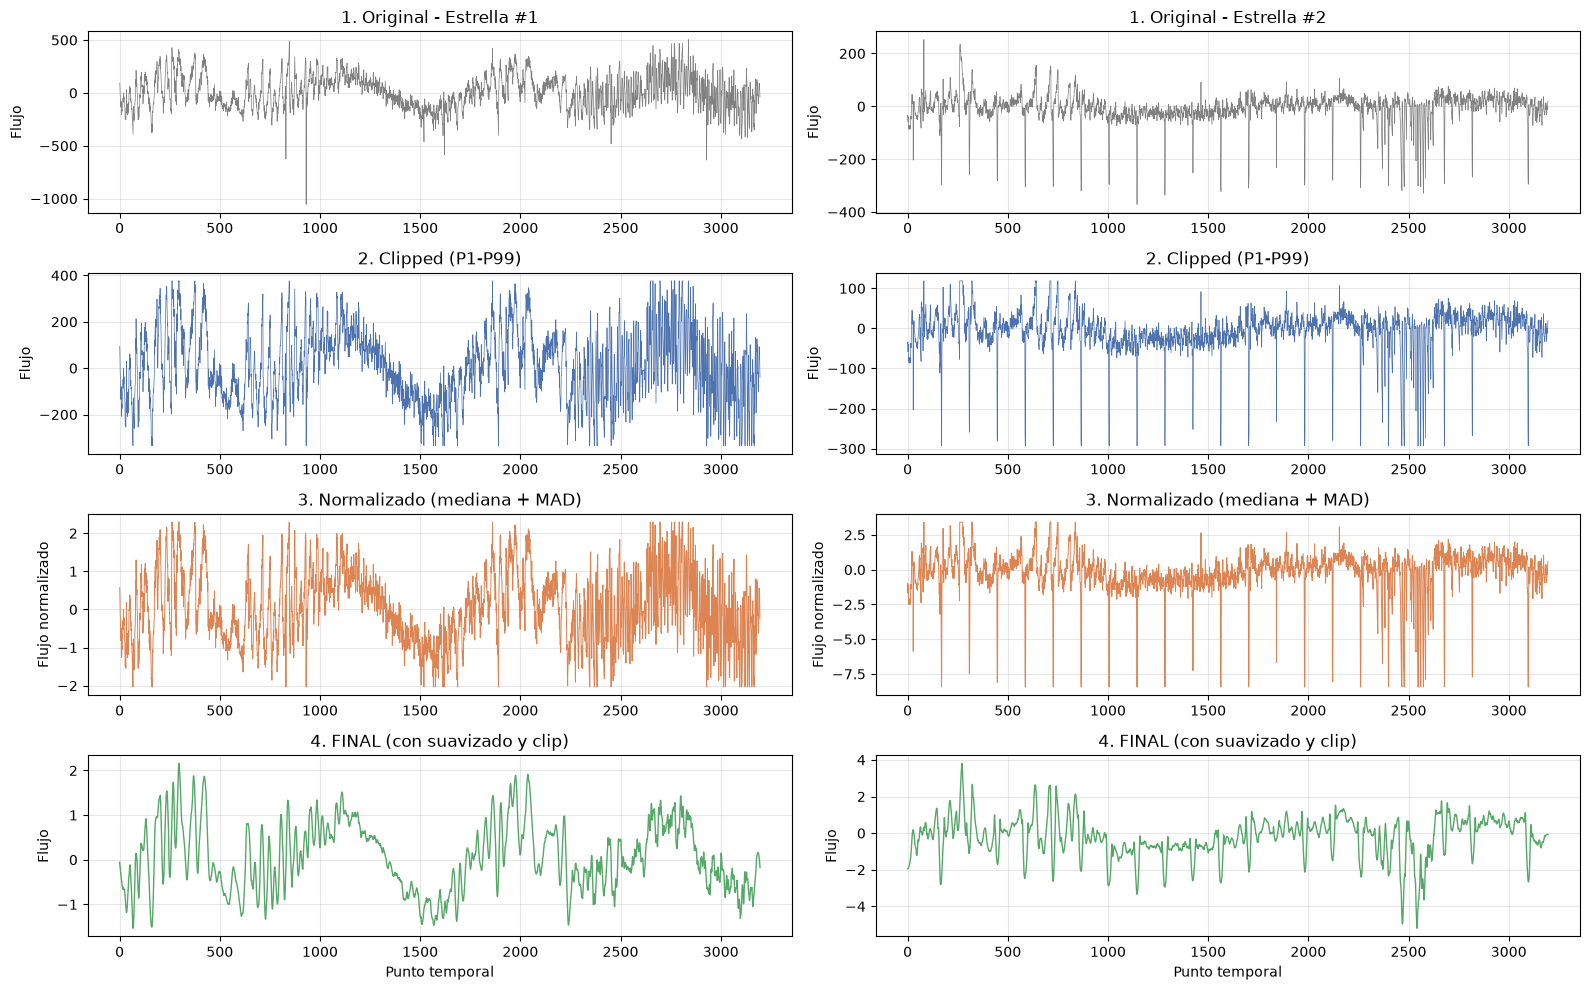

In [23]:
# ============================================================
# 22 — Visualización paso a paso del pipeline de preprocesamiento
# ============================================================
# En este bloque tomamos 2 estrellas CON planeta y mostramos cómo cambia
# su curva de luz a través de cada etapa del pipeline:
#
#   1) Señal original (cruda)
#   2) Clipping por percentiles (1–99)
#   3) Normalización robusta (mediana + MAD)
#   4) Pipeline final (suavizado + clipping final)
#
# Esto permite ver claramente:
#   - Cómo se reduce el ruido extremo
#   - Cómo se estabiliza la escala
#   - Cómo se preserva la forma del tránsito
#   - Cómo queda la señal final lista para modelado

con_planeta_idx = np.where(y_train == 2)[0][:2]

fig, axes = plt.subplots(4, 2, figsize=(16, 10))

for i, idx in enumerate(con_planeta_idx):
    # ------------------------------------------------------------
    # 1 — Señal original
    # ------------------------------------------------------------
    axes[0, i].plot(X_train[idx], linewidth=0.5, color='gray')
    axes[0, i].set_title(f'1. Original - Estrella #{i+1}')
    axes[0, i].set_ylabel('Flujo')
    axes[0, i].grid(True, alpha=0.3)
    
    # ------------------------------------------------------------
    # 2 — Clipping (percentiles 1–99)
    # ------------------------------------------------------------
    axes[1, i].plot(clip_outliers(X_train)[idx], linewidth=0.5, color='#4C72B0')
    axes[1, i].set_title('2. Clipped (P1-P99)')
    axes[1, i].set_ylabel('Flujo')
    axes[1, i].grid(True, alpha=0.3)
    
    # ------------------------------------------------------------
    # 3 — Normalización robusta (mediana + MAD)
    # ------------------------------------------------------------
    axes[2, i].plot(robust_normalize(clip_outliers(X_train))[idx], linewidth=0.7, color='#DD8452')
    axes[2, i].set_title('3. Normalizado (mediana + MAD)')
    axes[2, i].set_ylabel('Flujo normalizado')
    axes[2, i].grid(True, alpha=0.3)
    
    # ------------------------------------------------------------
    # 4 — Pipeline final (suavizado + clipping final)
    # ------------------------------------------------------------
    axes[3, i].plot(X_train_processed[idx], linewidth=1, color='#55A868')
    axes[3, i].set_title('4. FINAL (con suavizado y clip)')
    axes[3, i].set_ylabel('Flujo')
    axes[3, i].set_xlabel('Punto temporal')
    axes[3, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/05_pipeline_preprocesamiento.png', dpi=100, bbox_inches='tight')
plt.show()

# ============================================================
# Nota técnica
# ============================================================
# Este panel resume visualmente el impacto del pipeline:
#
#   ✔ La señal original puede tener ruido extremo y variabilidad no informativa.
#   ✔ El clipping elimina picos instrumentales sin alterar la estructura temporal.
#   ✔ La normalización robusta centra y escala la señal de forma resistente a outliers.
#   ✔ El suavizado Savitzky–Golay reduce ruido de alta frecuencia sin borrar tránsitos.
#
# El resultado final es una curva limpia, estable y lista para ser usada
# por modelos de clasificación basados en patrones temporales (CNN, LSTM,
# Transformers, XGBoost, SVM, etc.).


Lo Que Muestra el Gráfico
Estrella #2 (columna derecha) — Este es el caso estrella. Mira la fila 3 (naranja): hay caídas periódicas profundas que se repiten cada ~500 puntos. En la fila 4 (verde) esas caídas siguen ahí, perfectamente visibles y limpias. Ese es un tránsito planetario de libro de texto.

Estrella #1 (columna izquierda) — Aquí hay una lección importante: lo que parecía una señal ahora se ve como una oscilación suave y larga (probablemente variabilidad estelar intrínseca, no un tránsito). Esto significa que el dataset tiene falsos positivos: estrellas etiquetadas como "con planeta" que quizás son variables pulsantes. El modelo tendrá que aprender a distinguirlas.

Lo que ganamos con el pipeline:

Los outliers de ±1000 en original → domesticados a ±5 en final

Los tránsitos reales → preservados y realzados

La variabilidad lenta → conservada como contexto